# Series de tiempo financieras: oro y activos relacionados

Análisis diario del oro y de su relación con otros activos, con datos de TradingView:

1. Limpieza y estadísticas de retornos (volatilidad, asimetría, drawdown, VaR, CVaR)
2. Forma de la distribución: normal vs t de Student y backtest del VaR
3. Estacionariedad, eficiencia (razón de varianzas) y autocorrelación
4. ARIMA sobre el precio, con evaluación fuera de muestra
5. Volatilidad condicional: GARCH(1,1) y búsqueda entre GARCH, GJR-GARCH y EGARCH
6. VAR del sistema: causalidad de Granger, descomposición de varianza e impulso-respuesta
7. Tablero del analista

Las funciones están en el paquete `seriesfin/`; aquí solo se llaman y se comentan los resultados. Después de cada bloque, una celda de **lectura** (`seriesfin.interpretacion`) imprime métricas complementarias y la interpretación de los números que salieron, de modo que el texto cambia si cambian los datos o los tickers.

In [1]:
import numpy as np
import pandas as pd

from seriesfin import SEED, arima, datos, diagnostico, estadisticas, evaluacion, sistema, volatilidad
from seriesfin import graficos as g
from seriesfin import interpretacion as interp
from seriesfin.estilo import aplicar_estilo

aplicar_estilo()
np.random.seed(SEED)
pd.set_option('display.float_format', '{:,.4f}'.format)

H = {}   # hallazgos de cada sección, se usan en el tablero final

## Parámetros

Todo lo que se cambia seguido está aquí. `CORTE` separa entrenamiento y prueba: el test va desde esa fecha hasta el último dato disponible.

Los tickers van con el formato de TradingView `BOLSA:SÍMBOLO`: `COMEX:MGC1!` (micro oro, contrato continuo), `CME_MINI:MNQ1!` (micro Nasdaq), `AMEX:GLD`, `TVC:US10Y` (rendimiento del bono a 10 años). Sin iniciar sesión TradingView entrega como máximo 5000 barras diarias por símbolo; para usar una cuenta se definen las variables de entorno `TV_USUARIO` y `TV_CLAVE`.

`RIESGO_USD` es la pérdida diaria que se está dispuesto a aceptar por operación: con ella se traduce el VaR en un número de contratos. `VENTANA_CORR` es la ventana (en días hábiles) para la correlación y el beta recientes del sistema.

In [2]:
# Parte 1: retornos y riesgo de un contrato
TICKER = 'OANDA:USDJPY'  # 'MGC=F' o 'OANDA:XAUUSD'
INICIO_RIESGO = '2021-01-01'

# Parte 2: series de tiempo
PRINCIPAL = 'OANDA:USDJPY'       # serie para ARIMA y GARCH
SISTEMA = ['OANDA:USDJPY', 'OANDA:XAUUSD']   # activos del VAR
INICIO = '2017-01-01'
FIN = None                     # None = hasta hoy
CORTE = '2026-08-25'
H_FUT = 10                     # días hábiles a proyectar después del último dato
HORIZONTE_VOL = 10
GARCH_SOLO_TRAIN = False       # True = GARCH se ajusta solo con datos de entrenamiento

# Lecturas para el analista
RIESGO_USD = 1000               # pérdida diaria máxima aceptada por operación (USD)
VENTANA_CORR = 63              # ~3 meses para correlación y beta recientes

## 1. Datos y limpieza

TradingView entrega los futuros continuos (`COMEX:MGC1!`, `CME_MINI:MNQ1!`) **sin ajustar por roll**: en cada vencimiento aparece un salto en el precio que entra como si fuera un retorno. La limpieza marca esos retornos atípicos con un z-score robusto (MAD) pero no los borra, para que se vea cuánto pesan. Si se quiere una serie sin rolls, se puede usar un ETF como `AMEX:GLD` o `AMEX:IAU` (multiplicador 1).

Las barras diarias de futuros abren la tarde anterior (17:00 hora de Chicago); `datos.descargar` las asigna al día de negociación que les corresponde.

In [3]:
crudo = datos.descargar(TICKER, INICIO_RIESGO)
df, reporte = datos.limpiar(crudo)
df = df.dropna(subset=['log_ret'])
r = df['log_ret']

pd.Series(reporte, name=TICKER).to_frame()

you are using nologin method, data you access may be limited


,OANDA:USDJPY
filas_originales,1494
duplicados,0
nulos,0
filas_descartadas,0
outliers_marcados,2
filas_finales,1494
desde,2021-01-04
hasta,2026-10-05


**Lectura.** La pregunta aquí no es solo si los datos están limpios, sino *qué tan concentrado está el riesgo*. Si el 1% de los días explica una parte desproporcionada de la varianza, la desviación estándar es un mal resumen del riesgo: lo que define el resultado de una cartera son esos pocos días.

In [4]:
H.update(interp.limpieza(df, reporte, TICKER))


Lectura de los datos: USDJPY
────────────────────────────
  Observaciones                                            1,493   2021-01-04 a 2026-10-05
  Retornos marcados como atípicos                              2   0.13% de los días
  Varianza explicada por atípicos                           5.5%
  Varianza del 1% de días más extremos                     17.3%   en una normal sería ~8.4%
  Huecos de más de 4 días sin datos                            0

  Movimientos más grandes (en desviaciones robustas):
    2022-12-20   -3.88%   (8.5 σ)
    2022-11-10   -3.81%   (8.3 σ)
    2023-01-12   -2.45%   (5.4 σ)

  → El riesgo está concentrado: el 1% de los días explica 17% de la varianza total, más del doble
    de lo que pasaría con retornos normales. La volatilidad "promedio" esconde que unos pocos días
    hacen casi todo el daño; cualquier métrica basada solo en la desviación estándar subestima ese
    riesgo.
  → La serie no tiene rolls, así que los atípicos son movimientos reales del

## 2. Retornos y riesgo

El VaR y el CVaR se pasan a dólares por contrato con el multiplicador del futuro (10 onzas en el micro oro).

Volatilidad anual con outliers: 9.49% | sin outliers: 9.22%


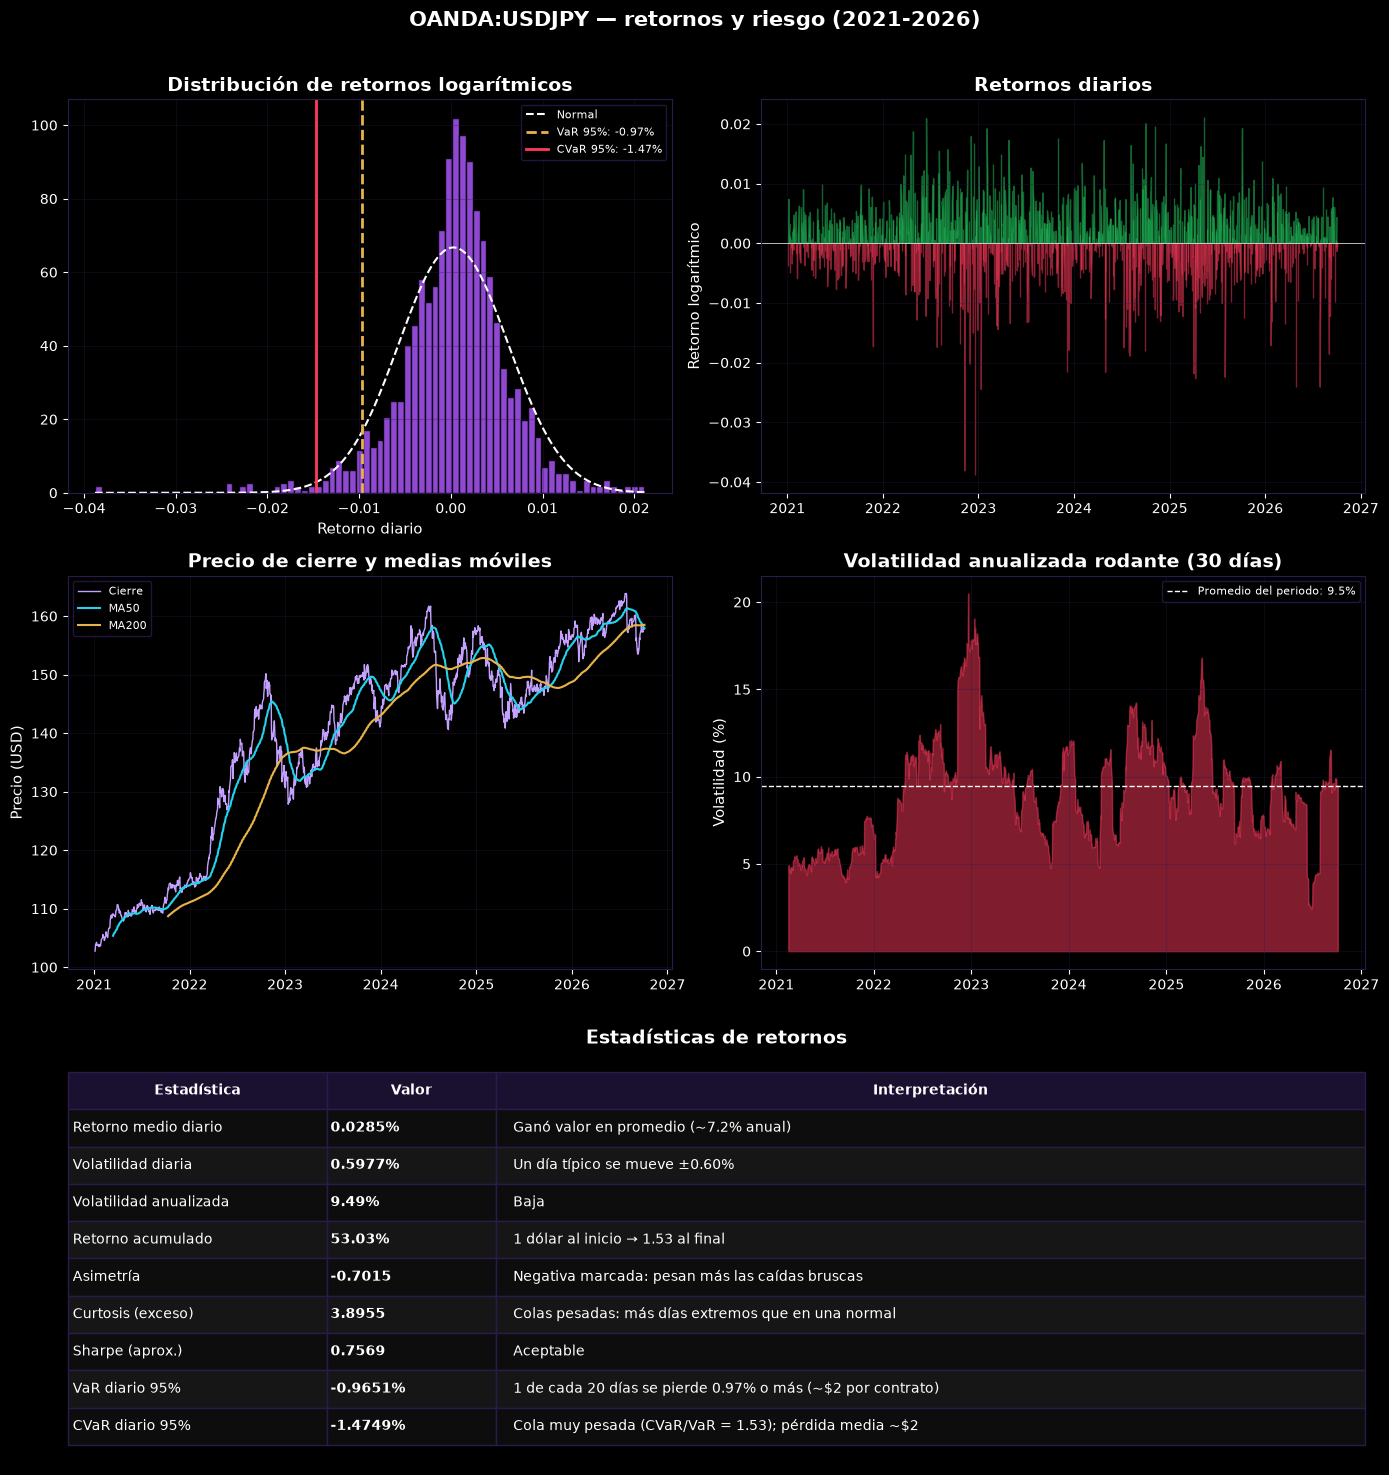

In [5]:
s = estadisticas.calcular_stats(r)
multiplicador = datos.multiplicador(TICKER)
filas = estadisticas.tabla_resumen(s, df['Close'].iloc[-1], multiplicador)

s_sin = estadisticas.calcular_stats(r[~df['outlier_ret']])
print(f"Volatilidad anual con outliers: {s['vol_a']:.2%} | sin outliers: {s_sin['vol_a']:.2%}")

g.dashboard(df, r, s, filas, TICKER, guardar='01_dashboard')

**Lectura.** Se agregan las métricas que un analista mira antes de dimensionar una posición:

- **Sortino y Calmar**: el Sharpe castiga igual la volatilidad al alza y a la baja; el Sortino solo la de baja. Con retornos simétricos Sortino ≈ √2 · Sharpe, así que lo informativo es el cociente frente a 1.41. El Calmar compara el retorno con el peor drawdown, que es lo que realmente hace cerrar una estrategia.
- **Drawdown y racha bajo el máximo**: cuánto dolor y cuánto tiempo hay que aguantar.
- **CVaR/VaR y VaR99/VaR95** frente a sus valores normales (1.25 y 1.41): miden qué tan pesada es la cola sin depender de la curtosis, que es inestable.
- **Régimen de volatilidad**: la volatilidad de los últimos 21 días ubicada en su propia historia. Las métricas de toda la muestra describen un promedio que puede no parecerse a hoy.
- **Contratos para `RIESGO_USD`**: el VaR 99% llevado a tamaño de posición.

In [6]:
H.update(interp.riesgo(r, s, df['Close'].iloc[-1], multiplicador, TICKER, RIESGO_USD))


Lectura de riesgo: USDJPY
─────────────────────────
  Retorno anual compuesto (CAGR)                           7.45%
  Volatilidad anual                                        9.49%
  Sharpe (rf = 0)                                           0.76
  Sortino (rf = 0)                                          1.04
  Máximo drawdown                                        -14.85%   2022-10-20 → 2023-01-13
  Drawdown actual                                         -3.70%
  Racha más larga bajo el máximo                        505 días   ~2.0 años
  Calmar (CAGR / |MDD|)                                     0.50
  Días positivos                                           56.4%
  Ganancia media / pérdida media                            0.88
  Profit factor (comprar y mantener)                        1.14

  Exposición por contrato                                   $158   precio 157.81 × 1
  VaR 95% / CVaR 95% (histórico)                 -0.97% / -1.47%   $2 / $2 por contrato
  VaR 99% / CVaR 99%

### Forma de la distribución

Si los retornos tienen colas más pesadas que la normal, un VaR calculado con la normal se queda corto. Se compara contra una t de Student ajustada por máxima verosimilitud.

Jarque-Bera:  1,058.00 (p = 1.81e-230)
Shapiro-Wilk: 0.9533 (p = 2e-21)
Se rechaza normalidad: con la normal se subestima el riesgo de cola.

t de Student: 3.61 grados de libertad (colas muy pesadas)
AIC normal: -11,047.9 | AIC t: -11,241.3 → mejor ajuste: t

Días a más de 3σ: 23 observados, 4.0 esperados con la normal, 23.7 con la t


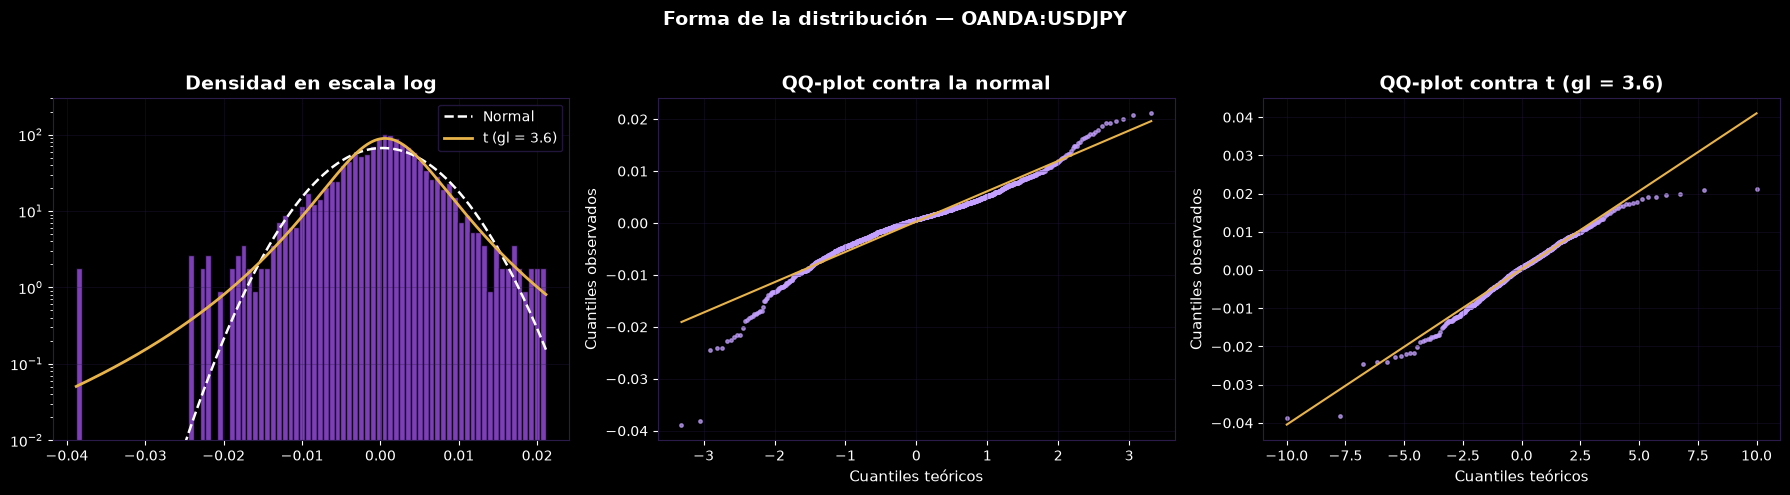

,Histórico,Normal,t de Student
Confianza,,,
95%,-0.9650,-0.9540,-0.8610
99%,-1.7930,-1.3610,-1.6060


In [7]:
ajuste = estadisticas.pruebas_normalidad(r)
estadisticas.reporte_normalidad(ajuste)
g.distribucion(r, ajuste, TICKER, guardar='02_distribucion')

# VaR diario en % según cada método
(ajuste['tabla_var'] * 100).round(3)

**Lectura.** Los grados de libertad de la t dicen más que la curtosis: con menos de 4 la curtosis teórica ni siquiera existe, y la muestral cambia mucho con un solo día extremo. Se traduce además la diferencia de colas a frecuencias ("cada cuántos años") y se hace un backtest de Kupiec para ver qué VaR entrega la cantidad de excepciones que promete.

In [8]:
H.update(interp.distribucion(r, ajuste))


Lectura de la distribución
──────────────────────────
  Grados de libertad de la t                                3.61
  Curtosis (exceso) implícita en la t           no existe (gl ≤ 4)
  Curtosis (exceso) muestral                                3.90
  Días a ±3σ: observados / normal                       23 / 4.0   5.7 veces lo esperado

  Caídas extremas: cada cuánto ocurren
    -3σ: 16 días (normal esperaría 2.0). Normal: una vez cada 3 años | datos: cada 0.4 años
    -4σ: 5 días (normal esperaría 0.0). Normal: una vez cada 125 años | datos: cada 1.2 años

  Backtest del VaR dentro de muestra (Kupiec, H0: frecuencia correcta)
    Nivel Método              VaR  Excepciones  Esperadas       p
    95%   Normal           -0.95%           78       74.7   0.693
    95%   t de Student     -0.86%          100       74.7   0.004  ← rechaza
    95%   Histórico        -0.97%           75       74.7   0.967
    99%   Normal           -1.36%           29       14.9   0.001  ← rechaza
    99%   

## 3. El sistema de activos

Desde aquí se trabaja con los activos de `SISTEMA` en fechas comunes. Los retornos van en % porque GARCH converge mejor en esa escala.

In [9]:
precios, ohlc, retornos = datos.cargar_sistema(SISTEMA, PRINCIPAL, INICIO, FIN)
serie = precios[PRINCIPAL]
ret = retornos[PRINCIPAL]
multiplicador_p = datos.multiplicador(PRINCIPAL)

print(f'{len(precios)} observaciones: {precios.index[0].date()} a {precios.index[-1].date()}')
datos.resumen_precios(precios, retornos)

2518 observaciones: 2017-01-03 a 2026-10-05


,Inicial,Final,Retorno (%),Vol. anual (%)
Ticker,,,,
OANDA:USDJPY,117.7500,157.8100,34.0000,8.7000
OANDA:XAUUSD,"1,158.8300","4,154.8200",258.5000,16.1000


Antes de modelar conviene revisar si la configuración tiene trampas: un test demasiado corto para evaluar, o una serie del sistema que no es un precio (los rendimientos de bonos se comportan distinto).

In [10]:
H.update(interp.revisar_configuracion(precios, SISTEMA, PRINCIPAL, CORTE))


Chequeo de la configuración
───────────────────────────
  Sin observaciones.


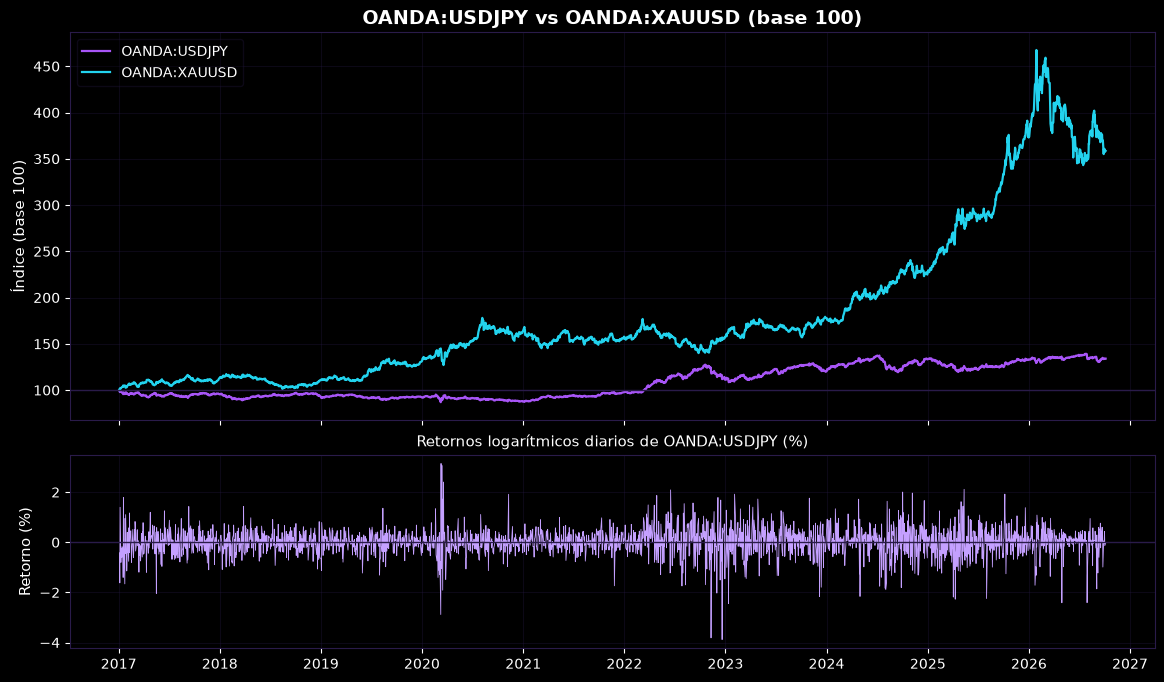

In [11]:
g.series(precios, ret, PRINCIPAL, guardar='03_series')

Los precios tienen tendencia; los retornos oscilan alrededor de cero, pero su amplitud no es constante. Esas rachas de días agitados (volatility clustering) son lo que modela GARCH más abajo.

### Estacionariedad

ADF y KPSS tienen hipótesis nulas opuestas, así que se usan juntas: una serie es estacionaria si ADF rechaza y KPSS no.

/Users/juancamilo/Documents/CODE/WP QUANT/series-tiempo-futuros TRADINGVIEW/seriesfin/diagnostico.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_adf = adfuller(x, autolag='AIC')[1]
/Users/juancamilo/Documents/CODE/WP QUANT/series-tiempo-futuros TRADINGVIEW/seriesfin/diagnostico.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_adf = adfuller(x, autolag='AIC')

,ADF p,KPSS p,Veredicto
Serie,,,
OANDA:USDJPY precio,0.9173,0.0100,No estacionaria
OANDA:USDJPY Δ precio,0.0000,0.1000,Estacionaria
OANDA:USDJPY retorno log,0.0000,0.1000,Estacionaria
OANDA:USDJPY retorno²,0.0000,0.0100,Ambigua


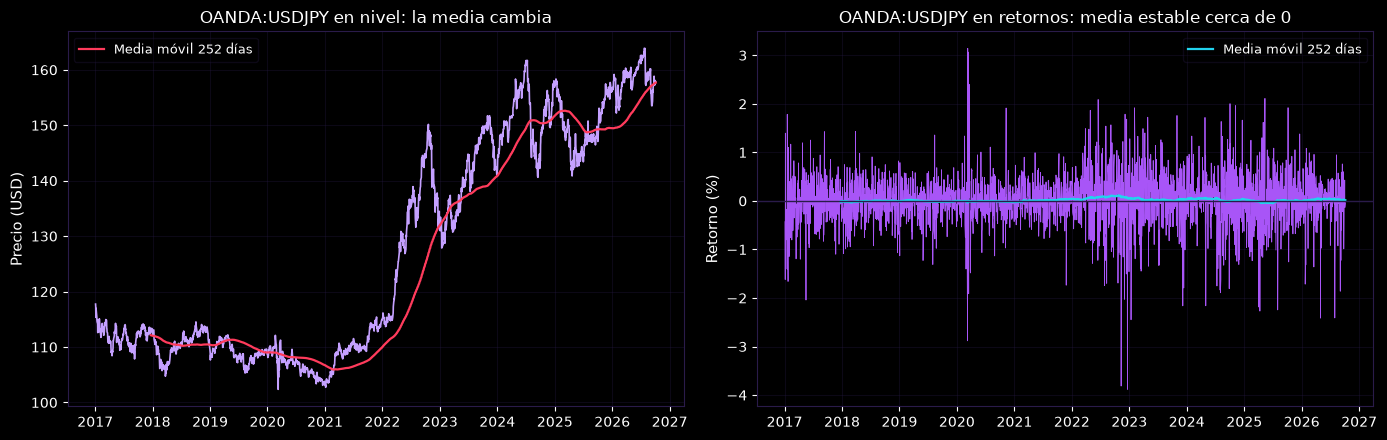

In [12]:
tabla_est = diagnostico.tabla_estacionariedad(serie, ret, PRINCIPAL)
display(tabla_est)
g.nivel_vs_retornos(serie, ret, PRINCIPAL)

El precio en nivel no es estacionario, por eso el ARIMA usa d = 1. Los retornos sí lo son, y sobre ellos trabajan GARCH y el VAR.

**Lectura.** ADF y KPSS responden si la serie es estacionaria, pero no si es *predecible*. Para eso se agrega la razón de varianzas de Lo-MacKinlay: si los retornos son un paseo aleatorio, la varianza a q días es q veces la diaria (VR = 1). VR > 1 indica que los movimientos se extienden (momentum) y VR < 1 que se corrigen (reversión). El z es robusto a heterocedasticidad, necesario porque la volatilidad cambia en el tiempo.

In [13]:
H.update(interp.estacionariedad(tabla_est, ret, PRINCIPAL))


Lectura de estacionariedad y eficiencia
───────────────────────────────────────
  OANDA:USDJPY precio                            No estacionaria   ADF p = 0.9173, KPSS p = 0.01
  OANDA:USDJPY Δ precio                             Estacionaria   ADF p = 0.0, KPSS p = 0.1
  OANDA:USDJPY retorno log                          Estacionaria   ADF p = 0.0, KPSS p = 0.1
  OANDA:USDJPY retorno²                                  Ambigua   ADF p = 0.0, KPSS p = 0.01

  Razón de varianzas de Lo-MacKinlay (paseo aleatorio: VR = 1)
    q (días)        VR   z robusto        p   lectura
    2            0.973       -0.93    0.350   consistente con paseo aleatorio
    5            0.943       -0.94    0.348   consistente con paseo aleatorio
    10           0.918       -0.89    0.373   consistente con paseo aleatorio
    20           0.937       -0.48    0.634   consistente con paseo aleatorio

  → El precio tiene raíz unitaria: no regresa a ningún nivel "justo" por sí solo. Cualquier
    estrategia de r

### Autocorrelación

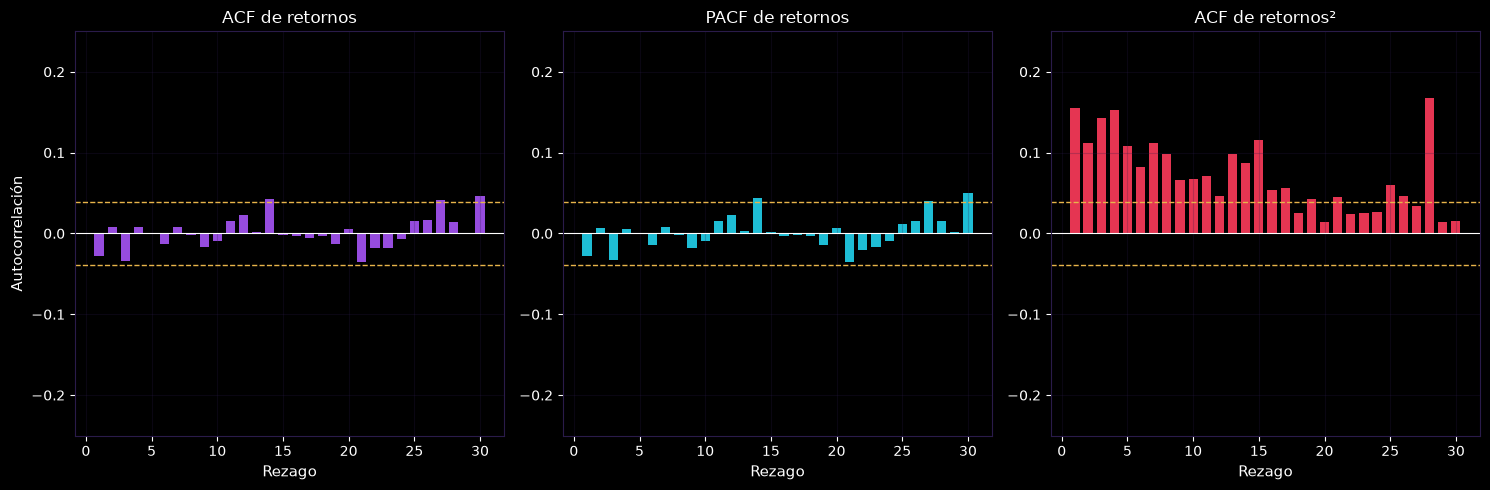

Rezagos significativos (de 30): retornos 3, retornos² 22


In [14]:
ac = diagnostico.autocorrelaciones(ret, nlags=30)
g.autocorrelaciones(ac, guardar='04_acf')

sig = diagnostico.rezagos_significativos(ac)
print(f"Rezagos significativos (de 30): retornos {sig['retornos']}, retornos² {sig['retornos²']}")

La ACF de los retornos es casi plana: la dirección del día siguiente es difícil de anticipar. La de los retornos al cuadrado sí persiste, o sea que la *magnitud* de los movimientos tiene memoria.

**Lectura.** Con miles de observaciones la banda de significancia es estrecha y casi cualquier efecto sale significativo. Por eso se reporta también el R² implícito (ρ²): cuánto de la varianza de mañana explica el retorno de hoy. Se mide además el efecto apalancamiento simple, corr(r hoy, r² mañana): si es negativo, las caídas anticipan volatilidad (típico de acciones); si es positivo, las subidas (frecuente en el oro como refugio).

In [15]:
H.update(interp.autocorrelacion(ret, ac, PRINCIPAL))


Lectura de autocorrelación
──────────────────────────
  ρ(1) de los retornos                                   -0.0273   banda ±0.0391
  R² implícito del día siguiente                          0.075%
  Ljung-Box(10) retornos                               p = 0.769
  ρ(1) de los retornos²                                  +0.1557
  Ljung-Box(10) retornos²                             p = <0.001
  Ljung-Box(10) |retornos|                            p = <0.001
  Primer rezago con ACF(r²) no significativa                  18
  corr(r hoy, r² mañana)                                 -0.0519   banda ±0.0391
  corr(r hoy, |r| mañana)                                -0.0632

  → La autocorrelación de los retornos es indistinguible de cero: lo que pasó ayer no dice nada
    útil sobre la dirección de hoy. Es lo esperable en un mercado líquido y eficiente.
  → La magnitud sí tiene memoria (Ljung-Box de r² con p <0.001); la ACF de r² se mantiene
    significativa hasta el rezago 18. Un día agitado a

## 4. ARIMA

El orden (p, 1, q) se elige por AIC en una rejilla de 0 a 3, usando solo el periodo de entrenamiento.

In [16]:
train, test = arima.dividir(serie, CORTE)
print(f'Train: {len(train)} obs. ({train.index[0].date()} a {train.index[-1].date()})')
print(f'Test:  {len(test)} obs. ({test.index[0].date()} a {test.index[-1].date()})')

tabla_aic, orden = arima.seleccionar_orden(train)
print(f'\nOrden elegido: ARIMA{orden}')
tabla_aic.head()

Train: 2488 obs. (2017-01-03 a 2026-08-24)
Test:  30 obs. (2026-08-25 a 2026-10-05)

Orden elegido: ARIMA(2, 1, 3)


,p,d,q,AIC,BIC
0,2,1,3,"5,505.8000","5,540.7200"
1,3,1,2,"5,505.8300","5,540.7400"
2,3,1,3,"5,507.0600","5,547.7900"
3,0,1,1,"5,517.3700","5,529.0000"
4,1,1,0,"5,517.3700","5,529.0100"


In [17]:
modelo_arima = arima.ajustar(train, orden)
resid = arima.residuos(modelo_arima, train, orden)

display(arima.coeficientes(modelo_arima))

# Ljung-Box, H0: los residuos son ruido blanco
arima.ljung_box(resid, orden).round(4)

,coef,p-valor
ar.L1,-0.8195,0.0000
ar.L2,-0.9608,0.0000
ma.L1,0.7999,0.0000
ma.L2,0.9513,0.0000
ma.L3,-0.0385,0.0098
sigma2,0.5331,0.0000


,lb_stat,lb_pvalue
10,1.2349,0.9415
20,10.4705,0.7892


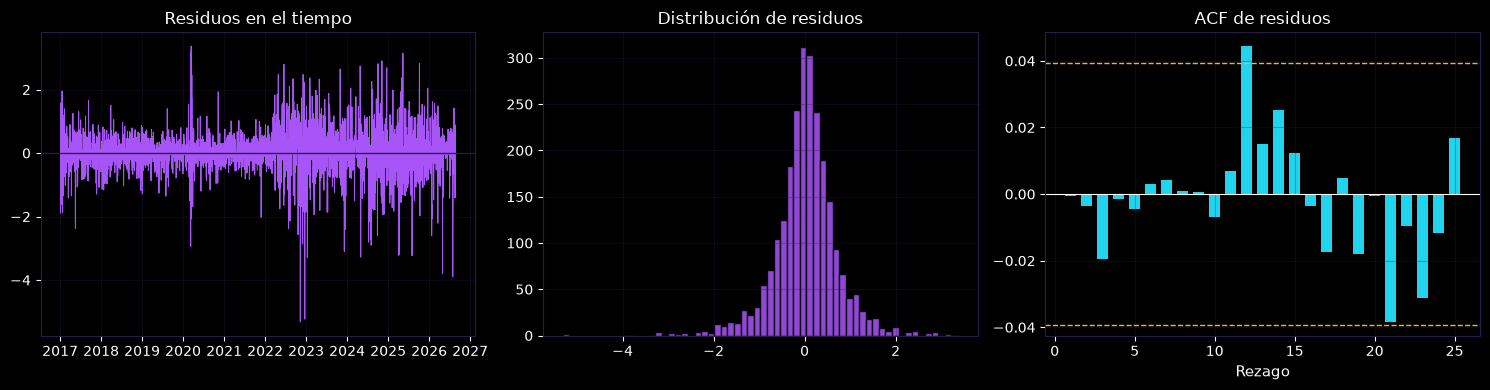

In [18]:
g.residuos_arima(resid)

**Lectura.** Tres cosas a revisar en un ARIMA de precios: si la diferencia de AIC con modelos más simples es real (menos de 2 puntos no distingue modelos), si los coeficientes AR y MA se cancelan entre sí (señal de sobreajuste) y si los residuos al cuadrado tienen memoria. Si la tienen, las bandas del pronóstico no son confiables porque suponen varianza constante.

In [19]:
H.update(interp.arima(modelo_arima, orden, resid, tabla_aic, train, test))


Lectura del ARIMA(2, 1, 3)
──────────────────────────
  Coeficientes ARMA significativos                        5 de 5   ar.L1, ar.L2, ma.L1, ma.L2, ma.L3
  ΔAIC frente al segundo mejor                              0.03
  ΔAIC frente al mejor modelo de 1 parámetro               11.57
  Desv. estándar del error (1 día)                          0.73   0.46% del último precio
  Ljung-Box(10) residuos                               p = 1.000
  Ljung-Box(10) residuos²                             p = <0.001
  Jarque-Bera residuos                                p = <0.001
  Observaciones train / test                          2,488 / 30

  → El segundo mejor modelo queda a 0.0 puntos de AIC: la elección del orden es frágil y puede
    cambiar con unos días más de datos. No conviene darle una interpretación económica al orden.
  → ar.L1 = -0.820 y ma.L1 = 0.800 casi se cancelan: las raíces AR y MA se anulan entre sí y el
    modelo se comporta como un paseo aleatorio con parámetros de adorno. E

### Pronóstico

Pronóstico dinámico sobre todo el test y `H_FUT` días hábiles más, con bandas al 80, 95 y 99%.

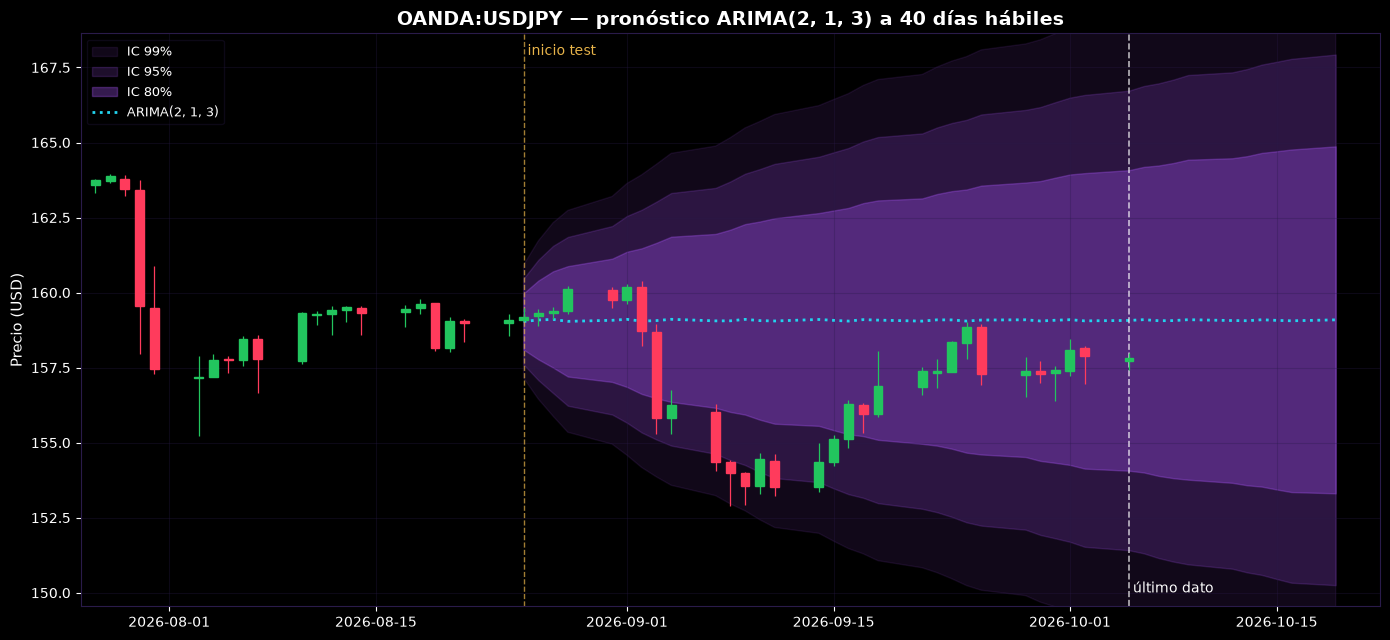

Ancho del IC 95%: $3 el primer día y $18 el día 40


In [20]:
pron = arima.pronosticar(modelo_arima, test, H_FUT)
g.pronostico_arima(ohlc, pron, CORTE, orden, PRINCIPAL, guardar='05_pronostico_arima')

ancho = pron['sup_95'] - pron['inf_95']
print(f'Ancho del IC 95%: ${ancho.iloc[0]:,.0f} el primer día y ${ancho.iloc[-1]:,.0f} el día {len(pron)}')

Un ARIMA(p,1,q) sin drift converge rápido al último precio conocido. A horizontes largos lo útil es el intervalo, no la línea central.

### Evaluación fuera de muestra

Cada pronóstico se compara con el benchmark que le corresponde: el de 1 paso contra el precio de ayer (paseo aleatorio) y el multi-paso contra el último precio del entrenamiento. La U de Theil es el cociente de RMSE: menor que 1 significa que el modelo le gana al ingenuo.

In [21]:
pred_1paso = evaluacion.pronostico_un_paso(modelo_arima, serie, train, test)
tabla_eval = evaluacion.evaluar(test, train, serie, pred_1paso, pron['media'], orden)
tabla_eval

,RMSE,MAE,MAPE (%),R²,U de Theil
Modelo,,,,,
"ARIMA(2, 1, 3) a 1 paso",0.9340,0.6806,0.4349,0.7732,1.0143
Ingenuo: precio de ayer,0.9208,0.6676,0.4267,0.7796,1.0000
"ARIMA(2, 1, 3) a 30 pasos",2.7998,2.2302,1.4330,-1.0379,0.9933
Ingenuo: último precio del train,2.8188,2.2472,1.4440,-1.0656,1.0000


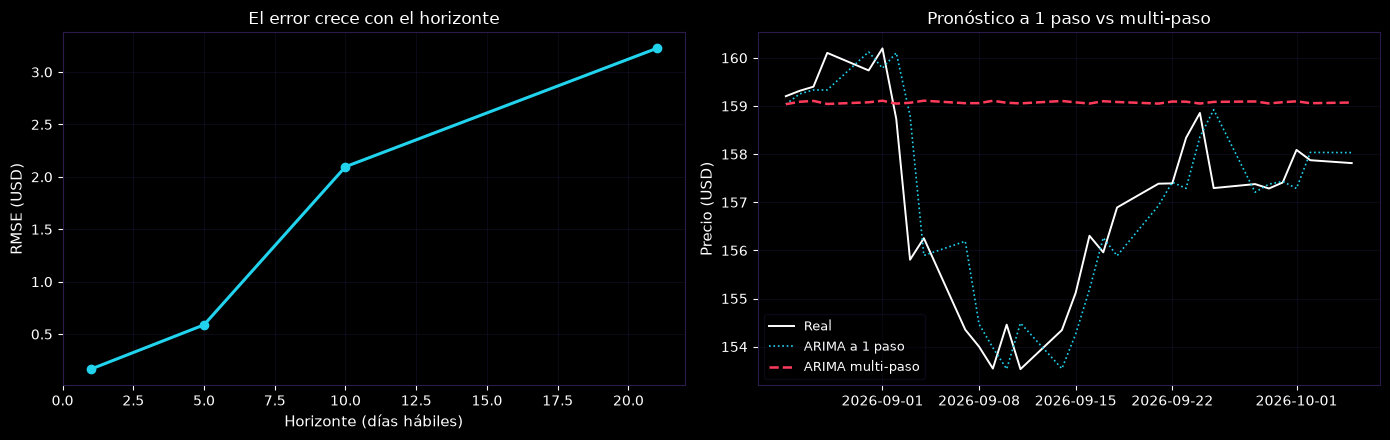

,RMSE,MAE,U de Theil
Horizonte,,,
1,0.1662,0.1662,1.6619
5,0.5884,0.4826,1.0574
10,2.0968,1.4644,0.9944
21,3.2255,2.6459,0.9941


In [22]:
tabla_h = evaluacion.error_por_horizonte(pron['media'], test, train)
g.error_horizonte(tabla_h, test, pred_1paso, pron['media'], guardar='06_error_horizonte')
tabla_h

El R² del pronóstico a 1 paso sale altísimo porque el precio de hoy se parece mucho al de ayer, no porque el modelo sepa algo. La U de Theil lo deja claro: si queda cerca de 1, el ARIMA no aporta nada frente al paseo aleatorio, que es lo esperable en un activo tan líquido.

**Lectura.** Una U de Theil de 0.98 o 1.02 no dice si la diferencia es real. Se agregan tres pruebas que sí lo dicen: **Diebold-Mariano** (¿los errores al cuadrado del modelo y del paseo aleatorio son distintos?), **acierto direccional** con prueba binomial (¿acierta la dirección más que una moneda?, que es lo que importa para operar) y **cobertura de las bandas** (¿el 95% de los precios cayó dentro de la banda del 95%?).

In [23]:
H.update(interp.evaluacion(serie, train, test, pred_1paso, pron, multiplicador_p))


Lectura de la evaluación fuera de muestra
─────────────────────────────────────────
  Días de prueba                                              30
  RMSE ARIMA a 1 paso                                       0.93   $1 por contrato
  RMSE paseo aleatorio                                      0.92   $1 por contrato
  U de Theil a 1 paso                                      1.014
  Diebold-Mariano (H0: igual precisión)                    +1.02   p = 0.314
  Acierto de dirección a 1 paso                            16/30   53.3%, binomial p = 0.856
  Sesgo medio del multi-paso (real − pron.)                -2.00
  Cobertura banda 80%                                        70%   nominal 80%
  Cobertura banda 95%                                        87%   nominal 95%
  Cobertura banda 99%                                       100%   nominal 99%

  → Diebold-Mariano no distingue al ARIMA del paseo aleatorio (U = 1.014). El modelo no agrega
    información sobre el precio de mañana más allá 

## 5. Volatilidad

Primero se confirma que hay efecto ARCH; si lo hay, tiene sentido modelar la varianza condicional.

ARCH-LM: 167.07 (p = 1.1e-30)


/opt/anaconda3/envs/juan/lib/python3.14/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


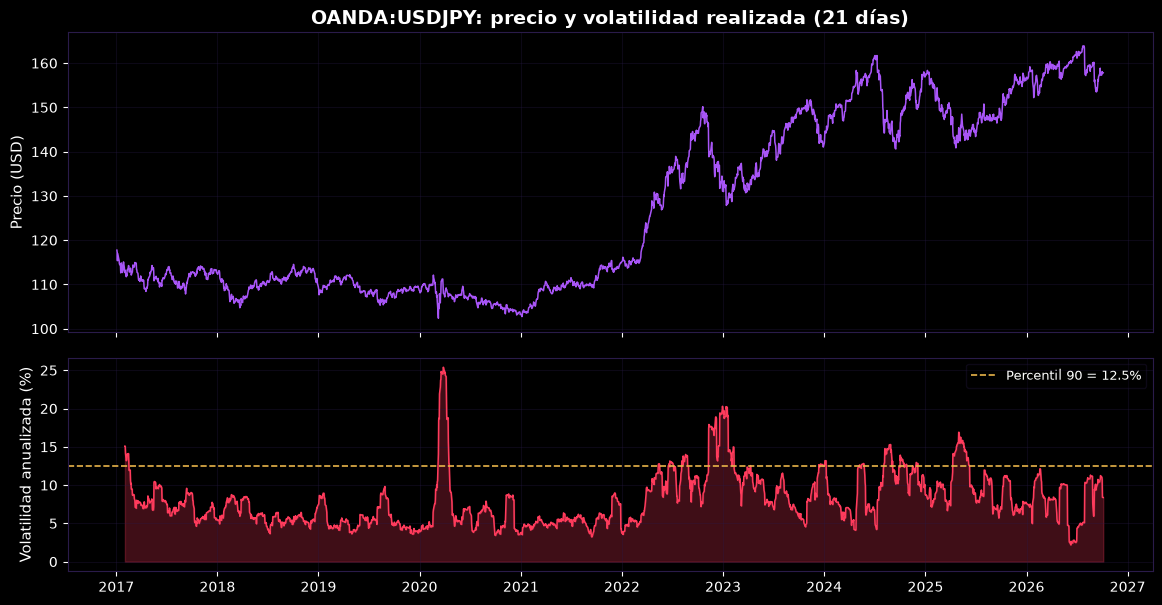

Días con volatilidad sobre el percentil 90: 250


In [24]:
lm, p_lm = diagnostico.prueba_arch(ret)
print(f'ARCH-LM: {lm:.2f} (p = {p_lm:.2g})')

dias_altos = g.clustering(serie, ret, PRINCIPAL, guardar='07_clustering')
print(f'Días con volatilidad sobre el percentil 90: {dias_altos}')

In [25]:
H.update(interp.efecto_arch(lm, p_lm, dias_altos, len(ret)))


Lectura del efecto ARCH
───────────────────────
  ARCH-LM(10)                                              167.1   p = <0.001
  Días sobre el percentil 90 de vol.                         250   9.9% de la muestra

  → Hay heterocedasticidad condicional clara: la varianza de hoy depende de los shocks recientes.
    Usar una sola volatilidad histórica para todo el periodo mezcla regímenes muy distintos.
    Modelar la varianza condicional está justificado.


### GARCH(1,1) con innovaciones t

Se usa la t de Student por lo visto en la sección 2: las colas son más pesadas que las de una normal.

,valor
mu,0.0266
omega,0.0070
alpha[1],0.0888
beta[1],0.8921
nu,4.7459


Persistencia α + β: 0.9809 (vida media de un shock: 35.9 días)
Volatilidad actual: 8.1% | largo plazo: 9.6%


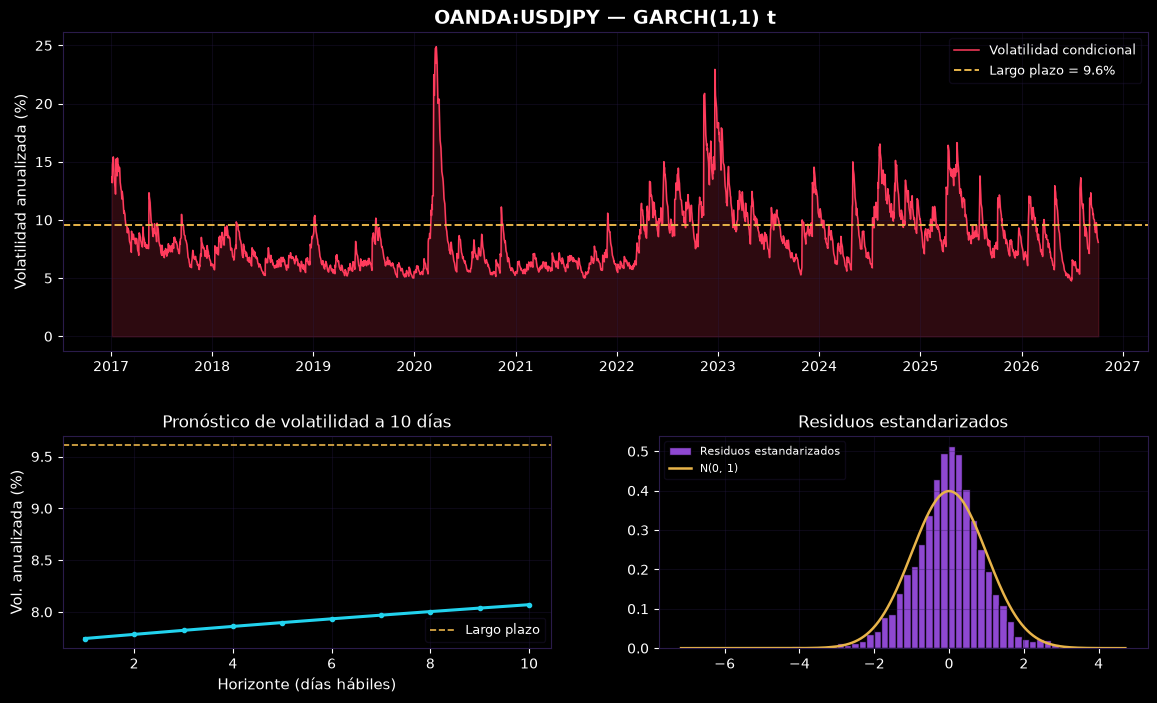

In [26]:
ret_garch = ret.loc[ret.index < pd.Timestamp(CORTE)] if GARCH_SOLO_TRAIN else ret

config_base = volatilidad.configuracion('Garch', p=1, o=0, q=1, dist='t')
garch_base = volatilidad.ajustar(ret_garch, config_base)
v_base = volatilidad.resumir(garch_base, config_base, HORIZONTE_VOL)

display(garch_base.params.round(5).to_frame('valor'))
print(f"Persistencia α + β: {v_base['persistencia']:.4f} "
      f"(vida media de un shock: {v_base['vida_media']:.1f} días)")
print(f"Volatilidad actual: {v_base['vol_cond'].iloc[-1]:.1f}% | largo plazo: {v_base['vol_lp']:.1f}%")

g.volatilidad(v_base, garch_base, PRINCIPAL)

### Búsqueda del modelo de volatilidad

GARCH, GJR-GARCH (asimetría con `o = 1`) y EGARCH, con órdenes 1 y 2 e innovaciones t o t asimétrica. Se descartan los ajustes que no convergen y se ordena por AIC.

In [27]:
tabla_vol, garch, config = volatilidad.buscar_modelo(ret_garch)
v = volatilidad.resumir(garch, config, HORIZONTE_VOL)

print(f"Mejor modelo por AIC: {config['nombre']}\n")
for linea in volatilidad.interpretar(v):
    print('-', linea)

tabla_vol.head(8)

Mejor modelo por AIC: EGARCH(1,1,1) t asimétrica

- Reacción a shocks (α = 0.1711): en EGARCH α actúa sobre log(σ²), no se compara directamente con el de un GARCH.
- Memoria (β = 0.9776): la volatilidad tarda en calmarse.
- Persistencia = 0.9776; un shock tarda 30.6 días hábiles en perder la mitad de su efecto.
- Asimetría (γ = -0.0309): las caídas suben la volatilidad más que las subidas (efecto apalancamiento).
- Grados de libertad = 4.72: colas muy pesadas.


,AIC,BIC,Log-verosimilitud
Modelo,,,
"EGARCH(1,1,1) t asimétrica","3,475.7800","3,516.6000","-1,730.8900"
"EGARCH(2,1,1) t asimétrica","3,476.3200","3,522.9700","-1,730.1600"
"EGARCH(1,1,2) t asimétrica","3,476.6400","3,523.2900","-1,730.3200"
"EGARCH(2,1,2) t asimétrica","3,478.3200","3,530.8000","-1,730.1600"
"EGARCH(1,0,1) t asimétrica","3,478.7200","3,513.7000","-1,733.3600"
"EGARCH(2,0,1) t asimétrica","3,479.4000","3,520.2100","-1,732.7000"
"GARCH(1,1) t asimétrica","3,479.5300","3,514.5200","-1,733.7700"
"GJR-GARCH(1,1,1) t asimétrica","3,479.8600","3,520.6800","-1,732.9300"


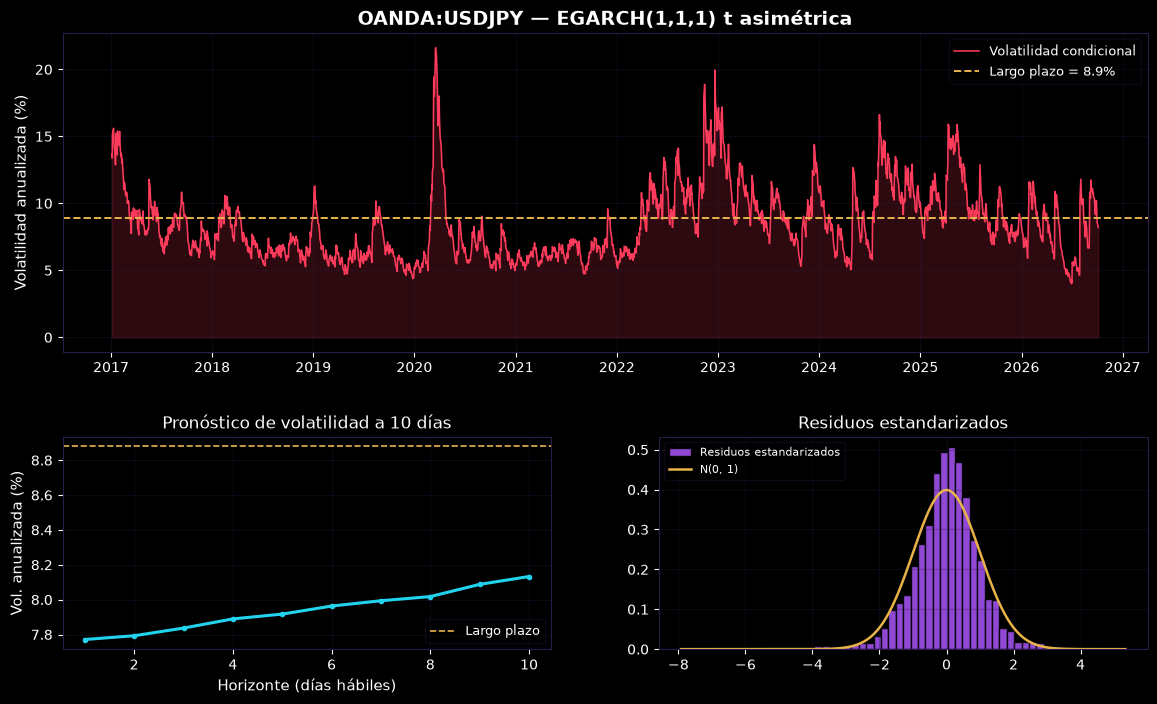

Volatilidad actual:          8.20%
Pronóstico para mañana:      7.77%
Pronóstico a 10 días:        8.13%
Nivel de largo plazo:        8.88%


In [28]:
g.volatilidad(v, garch, PRINCIPAL, guardar='08_volatilidad')

print(f"Volatilidad actual:          {v['vol_cond'].iloc[-1]:.2f}%")
print(f"Pronóstico para mañana:      {v['vol_pron'][0]:.2f}%")
print(f"Pronóstico a {HORIZONTE_VOL} días:        {v['vol_pron'][-1]:.2f}%")
print(f"Nivel de largo plazo:        {v['vol_lp']:.2f}%")

GARCH no dice hacia dónde va el precio, dice qué tan movido viene el camino. Eso es lo que sirve para dimensionar posiciones y ajustar stops.

**Lectura.** Esta es la sección más útil para operar, así que la lectura traduce el modelo a decisiones:

- **Régimen**: la volatilidad de hoy ubicada en el historial del modelo y frente a su nivel de largo plazo.
- **Asimetría**: cuánto más sube la varianza de mañana tras un shock de −2σ que tras uno de +2σ.
- **Rangos de precio** a 1 día y a `HORIZONTE_VOL` días (±1σ y ±2σ), con la volatilidad acumulada del pronóstico.
- **VaR condicional** con la distribución estimada de las innovaciones (t o t asimétrica), comparado con el VaR histórico: dice si hoy el riesgo está por encima o por debajo del promedio.
- **Contratos** para `RIESGO_USD` y **stop mínimo** a 2σ diarios, para no quedar dentro del ruido.
- **Diagnóstico**: si los residuos estandarizados al cuadrado ya no tienen memoria, el modelo capturó el clustering.

Las volatilidades de `volatilidad.resumir` vienen anualizadas; para los rangos y el VaR se pasan a diarias dividiendo por √252.

In [29]:
H.update(interp.volatilidad(garch, v, ret, serie.iloc[-1], multiplicador_p, HORIZONTE_VOL,
                            RIESGO_USD, tabla_vol, PRINCIPAL))


Lectura de la volatilidad: EGARCH(1,1,1) t asimétrica
─────────────────────────────────────────────────────
  ΔAIC frente al segundo modelo                             0.54   EGARCH(2,1,1) t asimétrica
  ΔAIC frente a GARCH(1,1)                                  3.75   GARCH(1,1) t asimétrica
  Parámetros no significativos                                 1   omega
  Persistencia                                            0.9776   vida media 30.6 días
  Impacto de −2σ vs +2σ en la varianza                     1.13x

  Volatilidad hoy (anual)                                   8.2%   percentil 54 del historial del modelo
  Volatilidad de largo plazo (anual)                        8.9%   hoy / largo plazo = 0.92
  Pronóstico mañana (diaria)                               0.49%   7.8% anual
  Pronóstico día 10 (anual)                                 8.1%
  Volatilidad acumulada a 10 días                          1.58%

  Precio de referencia                                    157.81
  Rango 

## 6. VAR del sistema

In [30]:
tabla_lags, rezagos = sistema.seleccionar_rezagos(retornos)
modelo_var = sistema.ajustar(retornos, rezagos)
print(f'VAR({rezagos}) | AIC {modelo_var.aic:.4f} | BIC {modelo_var.bic:.4f}')
tabla_lags

VAR(1) | AIC -1.3281 | BIC -1.3142


,Rezagos
AIC,0
BIC,0
HQIC,0
FPE,0


### Causalidad de Granger

p-valores. H0: los rezagos de la **columna** no ayudan a predecir la **fila** más allá de lo que la fila ya explica de sí misma.

In [31]:
sistema.matriz_granger(modelo_var)

,OANDA:USDJPY,OANDA:XAUUSD
OANDA:USDJPY,NaN,0.0834
OANDA:XAUUSD,0.0220,NaN


### Impulso-respuesta y pronóstico

La IRF ortogonalizada depende del orden de las variables (Cholesky). Por eso se dibuja también con el orden invertido (línea punteada): si las curvas casi coinciden, el resultado no depende del orden. Eso pasa cuando la correlación contemporánea de los residuos es baja.

Correlación contemporánea de los residuos: -0.384


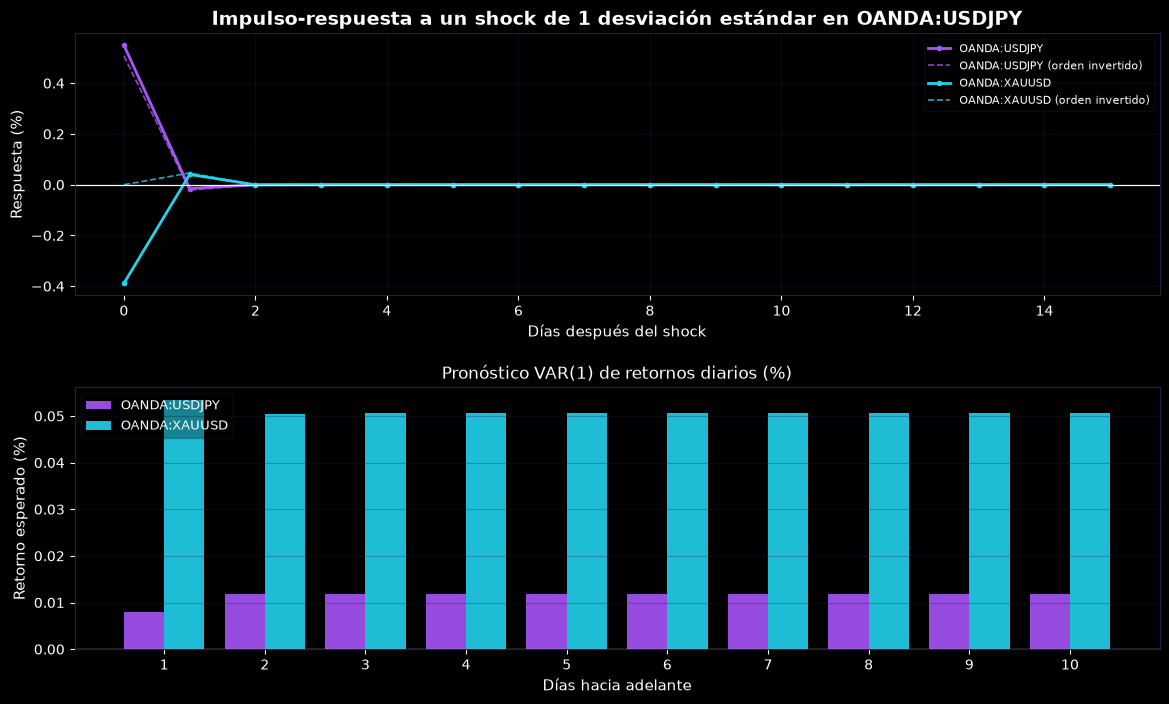

,OANDA:USDJPY,OANDA:XAUUSD
Día,,
1,0.0079,0.0535
2,0.0119,0.0503
3,0.0118,0.0506
4,0.0118,0.0506
5,0.0118,0.0506
6,0.0118,0.0506
7,0.0118,0.0506
8,0.0118,0.0506
9,0.0118,0.0506


In [32]:
irf = sistema.impulso_respuesta(retornos, rezagos, PRINCIPAL)
pron_var = sistema.pronosticar(modelo_var, retornos)

print(f'Correlación contemporánea de los residuos: {sistema.correlacion_residuos(modelo_var):.3f}')
g.var_sistema(irf, pron_var, PRINCIPAL, modelo_var.k_ar, guardar='09_var')
pron_var.round(4)

Los retornos pronosticados son diminutos, y está bien que así sea: el retorno esperado diario de un activo líquido es casi cero. Lo interesante del VAR es la estructura de respuestas cruzadas, no el nivel del pronóstico.

**Lectura.** Un p-valor de Granger bajo dice que el efecto existe, no que sea grande. La **descomposición de varianza** (FEVD) responde cuánto del riesgo del activo principal viene de shocks del otro. Se agregan la **correlación móvil** y el **beta** (total y reciente) porque para coberturas lo que importa es la relación del mismo día y su estabilidad; y la prueba de blancura de los residuos, que dice si los p-valores de Granger son confiables.

In [33]:
H.update(interp.sistema(modelo_var, retornos, PRINCIPAL, irf, VENTANA_CORR))


Lectura del sistema
───────────────────
  Rezagos del VAR                                              1
  Estable (raíces dentro del círculo)                         sí
  Blancura de residuos (Portmanteau)                   p = 0.016
  Correlación contemporánea de residuos                   -0.384

  Causalidad de Granger (H0: la causa no ayuda a predecir al destino)
        XAUUSD → USDJPY     p =   0.083   no significativo
        USDJPY → XAUUSD     p =   0.022   significativo

  Descomposición de varianza del error de USDJPY a 10 días
    explicada por shocks de XAUUSD: 0.1%

  USDJPY vs XAUUSD
  Correlación toda la muestra                             -0.385
  Correlación últimos 63 días                             -0.314   rango histórico -0.84 a +0.19
  Beta de USDJPY sobre XAUUSD (total)                     -0.209
  Beta últimos 63 días                                    -0.119
  % del tiempo con correlación negativa                      98%

  Respuesta de XAUUSD a un shock d

## 7. Resumen

In [34]:
pd.Series({
    f'Volatilidad anual {TICKER}': f"{s['vol_a']:.1%}",
    f'VaR 95% diario {TICKER}': f"{s['var']:.2%}",
    f'Grados de libertad t {TICKER}': f"{ajuste['t'][0]:.1f}",
    f'Orden ARIMA {PRINCIPAL}': str(orden),
    'U de Theil a 1 paso': f"{tabla_eval['U de Theil'].iloc[0]:.3f}",
    'Modelo de volatilidad': config['nombre'],
    'Volatilidad actual': f"{v['vol_cond'].iloc[-1]:.1f}%",
    f'Volatilidad a {HORIZONTE_VOL} días': f"{v['vol_pron'][-1]:.1f}%",
    'Vida media de un shock': f"{v['vida_media']:.1f} días",
    'Rezagos del VAR': str(rezagos),
}, name='Valor').to_frame()

,Valor
Volatilidad anual OANDA:USDJPY,9.5%
VaR 95% diario OANDA:USDJPY,-0.97%
Grados de libertad t OANDA:USDJPY,3.6
Orden ARIMA OANDA:USDJPY,"(2, 1, 3)"
U de Theil a 1 paso,1.014
Modelo de volatilidad,"EGARCH(1,1,1) t asimétrica"
Volatilidad actual,8.2%
Volatilidad a 10 días,8.1%
Vida media de un shock,30.6 días
Rezagos del VAR,1


### Tablero del analista

Junta lo que salió en cada sección: dónde está el mercado hoy (régimen y rangos), cuánto arriesgar (VaR, contratos, stop), qué es predecible y qué no, y los siguientes pasos. Las conclusiones se generan con los resultados, así que se actualizan solas al cambiar `CORTE`, los tickers o las fechas.

In [35]:
interp.resumen(H, PRINCIPAL, TICKER, RIESGO_USD)


Tablero del analista: USDJPY
────────────────────────────

  Dónde estamos
  Último precio                                           157.81
  Régimen de volatilidad (GARCH)                          NORMAL   percentil 54, 8.2% anual
  Tendencia de la volatilidad                          a la baja   8.2% → 8.1% en 10 días
  Rango probable mañana (±1σ)                          157 – 159
  Rango extremo mañana (±2σ)                           156 – 159
  Rango probable a 10 días (±1σ)                       155 – 160

  Gestión del riesgo
  VaR 99% de mañana por contrato                              $2
  Contratos con $1,000 de riesgo                             472
  Stop mínimo sugerido (2σ)                              1.5 pts   $2 por contrato
  Pérdida media en el peor 1% de días                         $4   USDJPY, histórico
  Máximo drawdown histórico                               -14.9%

  Qué es predecible
  Dirección del precio                               sin ventaja   U de Thei

**Limitaciones**

- Futuros continuos de TradingView sin ajuste por roll.
- No hay costos de transacción ni re-estimación de los modelos en el test (walk-forward).
- El backtest del VaR de la sección 2 es dentro de muestra.
- Los rangos y el tamaño de posición suponen que la distribución estimada sigue vigente mañana; en eventos programados (Fed, CPI, empleo) el riesgo real es mayor.
- Es un ejercicio de análisis, no una recomendación de inversión.